# Figure 2 — Spatial modulation is layer-specific from Day 1

**Panel A** — Population heatmaps split by layer (4 side-by-side, Parula, sorted by preferred position)  
**Panel B** — Violin plot per layer with per-animal median dots overlaid (shows both distribution + replication)

In [ ]:
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import h5py
from itertools import combinations
import matplotlib as mpl

# ── Font (apply globally so both panels match) ────────────────────────────────
mpl.rcParams['font.family']      = 'Arials'
mpl.rcParams['font.weight']      = 'normal'
mpl.rcParams['axes.titleweight'] = 'normal'
mpl.rcParams['axes.labelweight'] = 'normal'

# ── GLOBAL CONFIG ─────────────────────────────────────────────────────────────
PARENT_DIR   = r'D:\V1_SpatialModulation\2p\V1_prism'
LAYER_ORDER  = ['L2/3', 'L4', 'L5', 'L6']
LAYER_COLORS = {'L2/3': '#1E88E5', 'L4': '#FF9800', 'L5': '#4CAF50', 'L6': '#E53935'}
LANDMARKS    = {32: 'LD1', 60: 'LD2', 88: 'LD3', 116: 'LD4'}
SMOOTH_SIGMA = 1.0

OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('')), 'Poster', 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Parula colormap
PARULA = LinearSegmentedColormap.from_list('parula', [
    (0.2422, 0.1504, 0.6603), (0.2108, 0.3706, 0.9717),
    (0.0196, 0.5804, 0.8745), (0.0863, 0.6510, 0.7490),
    (0.1961, 0.6980, 0.6039), (0.3647, 0.7412, 0.5176),
    (0.6275, 0.7647, 0.3843), (0.8510, 0.7882, 0.1961),
    (0.9686, 0.8235, 0.0667), (0.9765, 0.9843, 0.0510),
])
print('Config loaded. Landmarks:', LANDMARKS)

Config loaded. Landmarks: {32: 'LD1', 60: 'LD2', 88: 'LD3', 116: 'LD4'}


In [53]:
# Load all Day-1 sessions: tuning curves (per layer) + SMI values

def extract_animal_day(filepath):
    m_a = re.search(r'(JSY\d+)', filepath)
    m_d = re.search(r'[Dd]ay(\d+)', filepath)
    return (m_a.group(1) if m_a else None, int(m_d.group(1)) if m_d else None)

# ── Find one Day-1 smi+preproc pair per animal ────────────────────────────────
smi_files = glob.glob(os.path.join(PARENT_DIR, '**', '*_smi_results.h5'), recursive=True)

by_animal = {}   # animal → (day, smi_path)
for path in smi_files:
    animal, day = extract_animal_day(path)
    if animal is None or day is None:
        continue
    if animal not in by_animal or day < by_animal[animal][0]:
        by_animal[animal] = (day, path)

# ── Load data ─────────────────────────────────────────────────────────────────
# heatmap_data[layer] = list of (tuning_norm, preferred_positions) per session
heatmap_data = {l: {'tuning': [], 'pp': [], 'bin_centers': None} for l in LAYER_ORDER}
# smi_data[layer]     = list of arrays (one per animal)
smi_data     = {l: {} for l in LAYER_ORDER}   # animal → np.array of SMI values

print(f'Day-1 sessions found: {len(by_animal)} animals\n')

for animal, (day, smi_path) in sorted(by_animal.items()):
    session_dir  = os.path.dirname(smi_path)
    preproc_files = glob.glob(os.path.join(session_dir, '*preproc*.h5'))

    if not preproc_files:
        print(f'  SKIP {animal} Day {day} — no preproc file')
        continue

    print(f'  Loading {animal} Day {day}')

    with h5py.File(preproc_files[0], 'r') as f:
        norm_act    = f['norm_spatial_activity'][:]   # (N_cells, N_laps, N_bins)
        bin_centers = f['bin_centers'][:]
    mean_tuning = np.nanmean(norm_act, axis=1)        # (N_cells, N_bins)

    with h5py.File(smi_path, 'r') as f:
        for lk in f['layer_smi'].keys():
            lg         = f['layer_smi'][lk]
            layer_name = lg.attrs.get('original_name', lk.replace('_', '/'))
            if layer_name not in LAYER_ORDER:
                continue
            rv  = lg['reliable_valid_cells'][:].astype(int)
            pp  = lg['preferred_positions'][:]
            smi = lg['SMI'][:] if 'SMI' in lg else np.array([])

            if len(rv) == 0:
                continue

            # Tuning: mean across all laps, then smooth + row-normalise
            tuning = mean_tuning[rv].copy()
            for i in range(len(tuning)):
                tuning[i] = gaussian_filter1d(tuning[i], sigma=SMOOTH_SIGMA)
            row_max = tuning.max(axis=1, keepdims=True)
            row_max[row_max == 0] = 1
            tuning = tuning / row_max

            heatmap_data[layer_name]['tuning'].append(tuning)
            heatmap_data[layer_name]['pp'].append(pp)
            heatmap_data[layer_name]['bin_centers'] = bin_centers
            smi_data[layer_name][animal] = smi

print('\nCell counts per layer:')
for l in LAYER_ORDER:
    n = sum(len(t) for t in heatmap_data[l]['tuning'])
    n_animals = len(smi_data[l])
    print(f'  {l}: {n} cells from {n_animals} animals')

Day-1 sessions found: 7 animals

  Loading JSY040 Day 1
  Loading JSY041 Day 1
  Loading JSY044 Day 1
  Loading JSY051 Day 1
  Loading JSY052 Day 1
  Loading JSY054 Day 1
  Loading JSY055 Day 1

Cell counts per layer:
  L2/3: 642 cells from 7 animals
  L4: 802 cells from 7 animals
  L5: 441 cells from 7 animals
  L6: 211 cells from 7 animals


Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\Figure2_PanelA_Heatmaps.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\Figure2_PanelA_Heatmaps.png


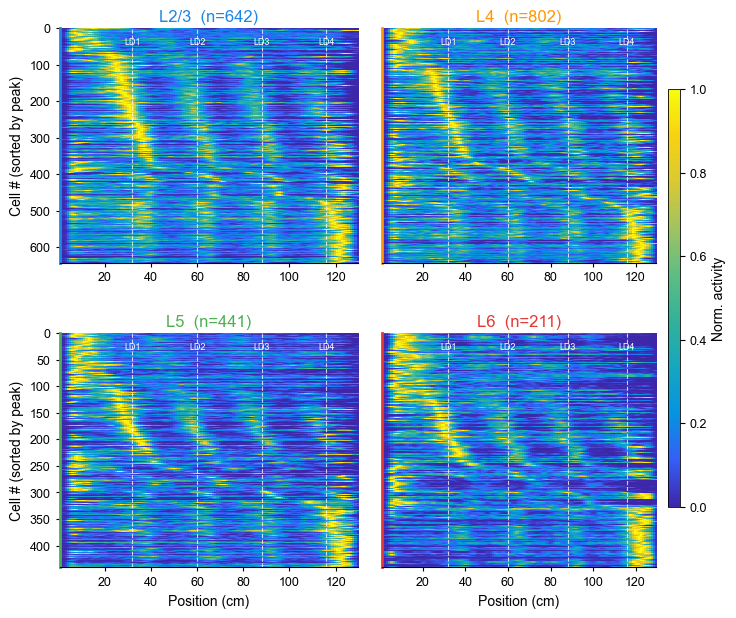

In [54]:
# Panel A — Population heatmaps: 2×2 grid (L2/3, L4 top; L5, L6 bottom)
# FIG_H shared with Panel B so both export at the same height
FIG_H = 7.0

fig_a, axes = plt.subplots(2, 2, figsize=(8.0, FIG_H),
                            gridspec_kw={'wspace': 0.08, 'hspace': 0.3})
axes_flat = axes.flatten()

for idx, (ax, layer) in enumerate(zip(axes_flat, LAYER_ORDER)):
    ld    = heatmap_data[layer]
    color = LAYER_COLORS[layer]
    row, col = divmod(idx, 2)

    if not ld['tuning']:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, color='gray', fontsize=10)
        ax.set_title(layer, color=color, fontsize=12)
        continue

    tuning_all    = np.concatenate(ld['tuning'], axis=0)
    pp_all        = np.concatenate(ld['pp'],     axis=0)
    order         = np.argsort(pp_all)
    tuning_sorted = tuning_all[order]
    n_cells       = len(order)

    bc            = ld['bin_centers']
    pos_min, pos_max = bc[0], bc[-1]

    im = ax.imshow(tuning_sorted, aspect='auto', cmap=PARULA, vmin=0, vmax=1,
                   extent=[pos_min, pos_max, n_cells, 0],
                   interpolation='nearest')

    for lm_pos, lm_lbl in LANDMARKS.items():
        ax.axvline(lm_pos, color='white', lw=0.8, ls='--', alpha=0.75)

    for lm_pos, lm_lbl in LANDMARKS.items():
        ax.text(lm_pos, n_cells * 0.04, lm_lbl, ha='center', va='top',
                fontsize=6.5, color='white', clip_on=True)

    ax.set_xlim(pos_min, pos_max)
    ax.set_ylim(n_cells, 0)
    ax.set_title(f'{layer}  (n={n_cells})', color=color, fontsize=12, pad=5)

    if row == 1:
        ax.set_xlabel('Position (cm)', fontsize=10)
    ax.tick_params(axis='x', labelsize=9, length=3, width=0.8)

    if col == 0:
        ax.set_ylabel('Cell # (sorted by peak)', fontsize=10)
        ax.tick_params(axis='y', labelsize=9, length=3, width=0.8)
    else:
        ax.set_yticks([])
        ax.tick_params(axis='y', left=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_color(color)
    ax.spines['left'].set_linewidth(2.0)

cbar = fig_a.colorbar(im, ax=axes[:, 1], fraction=0.04, pad=0.04, aspect=35)
cbar.set_label('Norm. activity', fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(0.6)

for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'Figure2_PanelA_Heatmaps{ext}')
    fig_a.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

In [55]:
# Statistics for Panel B (Mann-Whitney pairwise + FDR)

def fdr_bh(p_values):
    p = np.array(p_values)
    n = len(p)
    order = np.argsort(p)
    p_adj = np.minimum(p[order] * n / np.arange(1, n + 1), 1.0)
    p_adj = np.minimum.accumulate(p_adj[::-1])[::-1]
    result = np.empty(n)
    result[order] = p_adj
    return result

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

pooled_smi = {l: np.concatenate(list(smi_data[l].values()))
              if smi_data[l] else np.array([])
              for l in LAYER_ORDER}

valid = [pooled_smi[l] for l in LAYER_ORDER if len(pooled_smi[l]) > 0]
kw_stat, kw_p = stats.kruskal(*valid)
print(f'Kruskal-Wallis: H={kw_stat:.2f}, p={kw_p:.2e}')

pairs  = list(combinations(LAYER_ORDER, 2))
p_raw  = [stats.mannwhitneyu(pooled_smi[la], pooled_smi[lb],
                              alternative='two-sided')[1]
          if len(pooled_smi[la]) > 0 and len(pooled_smi[lb]) > 0
          else 1.0
          for la, lb in pairs]
p_adj  = fdr_bh(p_raw)

pair_stats = {}
print('\nPairwise (FDR-adjusted):')
for (la, lb), pr, pa in zip(pairs, p_raw, p_adj):
    sig = sig_label(pa)
    pair_stats[(la, lb)] = {'p_adj': pa, 'sig': sig}
    print(f'  {la} vs {lb}: p_adj={pa:.2e}  {sig}')

Kruskal-Wallis: H=42.99, p=2.47e-09

Pairwise (FDR-adjusted):
  L2/3 vs L4: p_adj=1.49e-01  ns
  L2/3 vs L5: p_adj=5.12e-07  ***
  L2/3 vs L6: p_adj=7.03e-06  ***
  L4 vs L5: p_adj=7.33e-05  ***
  L4 vs L6: p_adj=1.80e-04  ***
  L5 vs L6: p_adj=4.07e-01  ns


Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\Figure2_PanelB_Violin.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\Figure2_PanelB_Violin.png


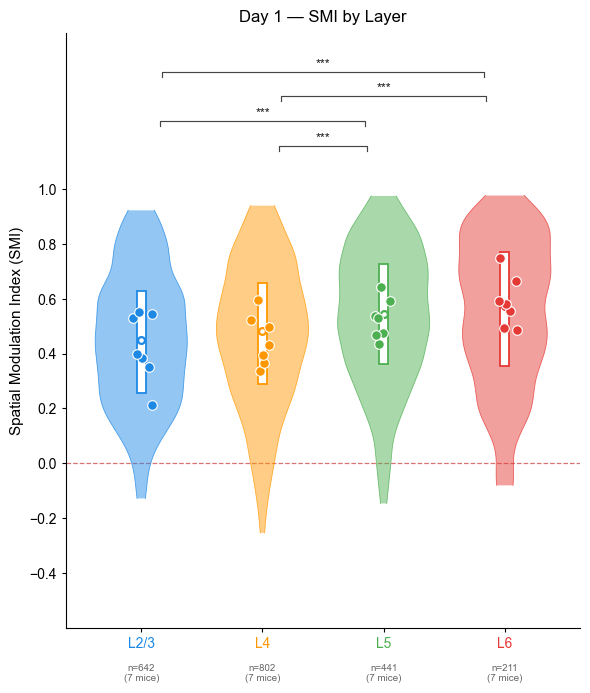

In [56]:
# Panel B — Violin + per-animal dots + significance brackets
# Uses FIG_H from Panel A cell so both figures export at identical height
from scipy.stats import gaussian_kde

BW        = 0.22
V_WIDTH   = 0.38
BOX_W     = 0.075
DOT_S     = 48
TAIL_CLIP = (1, 99)

def smooth_violin(ax, data, xi, color, width=V_WIDTH, bw=BW, alpha=0.48):
    kde  = gaussian_kde(data, bw_method=bw)
    ylo  = np.percentile(data, TAIL_CLIP[0])
    yhi  = np.percentile(data, TAIL_CLIP[1])
    ys   = np.linspace(ylo, yhi, 512)
    dens = kde(ys)
    dens = dens / dens.max() * width
    xs   = np.concatenate([xi - dens, (xi + dens)[::-1]])
    yvs  = np.concatenate([ys, ys[::-1]])
    ax.fill(xs, yvs, color=color, alpha=alpha, zorder=2, lw=0)
    ax.plot(xi + dens, ys, color=color, lw=0.6, alpha=0.75, zorder=3)
    ax.plot(xi - dens, ys, color=color, lw=0.6, alpha=0.75, zorder=3)

def box_overlay(ax, data, xi, color, bw=BOX_W):
    q1, med, q3 = np.percentile(data, [25, 50, 75])
    ax.add_patch(plt.Rectangle((xi - bw/2, q1), bw, q3 - q1,
                                facecolor='white', edgecolor=color,
                                lw=1.3, zorder=5))
    ax.scatter([xi], [med], s=24, color='white', edgecolors=color,
               linewidths=1.6, zorder=6)

def animal_dots(ax, layer, xi, color, rng):
    meds = [np.median(v) for v in smi_data[layer].values() if len(v) > 0]
    if not meds:
        return
    jx = rng.uniform(-0.10, 0.10, size=len(meds))
    ax.scatter(xi + jx, meds, s=DOT_S, color=color,
               edgecolors='white', linewidths=0.8, zorder=7)

def assign_bracket_levels(sig_pairs_xy):
    ordered = sorted(sig_pairs_xy, key=lambda b: (b[1] - b[0], b[0]))
    placed  = []
    for xa, xb, lbl in ordered:
        level = 0
        while any(lv == level and xa < xb2 and xb > xa2
                  for xa2, xb2, _, lv in placed):
            level += 1
        placed.append((xa, xb, lbl, level))
    return placed

def draw_brackets(ax, placed, y_start, b_step=0.09, b_h=0.018, inset=0.12):
    for xa, xb, lbl, level in placed:
        span   = xb - xa
        indent = inset * (1 + 0.15 * span)
        x0, x1 = xa + indent, xb - indent
        y = y_start + level * b_step
        ax.plot([x0, x0, x1, x1], [y, y + b_h, y + b_h, y],
                color='#444444', lw=0.85, clip_on=False, zorder=8)
        ax.text((x0 + x1) / 2, y + b_h + 0.005, lbl,
                ha='center', va='bottom', fontsize=9,
                fontfamily='Arial', color='#222222', zorder=9)

# ── Figure — same height as Panel A ───────────────────────────────────────────
fig_b, ax = plt.subplots(figsize=(6.0, FIG_H))
rng = np.random.default_rng(1)

for i, layer in enumerate(LAYER_ORDER):
    data  = pooled_smi[layer]
    color = LAYER_COLORS[layer]
    if len(data) < 5:
        continue
    smooth_violin(ax, data, i, color)
    box_overlay(ax, data, i, color)
    animal_dots(ax, layer, i, color, rng)

ax.axhline(0, color='#C62828', lw=0.9, ls='--', alpha=0.65, zorder=1)

sig_triples = [(LAYER_ORDER.index(la), LAYER_ORDER.index(lb), info['sig'])
               for (la, lb), info in pair_stats.items() if info['sig'] != 'ns']
placed = assign_bracket_levels(sig_triples)

Y_MAX  = 1.1
b_step = 0.09
b_h    = 0.018
draw_brackets(ax, placed, y_start=Y_MAX + 0.04, b_step=b_step, b_h=b_h)
max_level = max((lv for _, _, _, lv in placed), default=0) if placed else 0

ax.set_xticks(range(len(LAYER_ORDER)))
ax.set_xticklabels(LAYER_ORDER, fontsize=12)
for tick, layer in zip(ax.get_xticklabels(), LAYER_ORDER):
    tick.set_color(LAYER_COLORS[layer])

for i, layer in enumerate(LAYER_ORDER):
    n   = len(pooled_smi[layer])
    n_a = len([v for v in smi_data[layer].values() if len(v) > 0])
    ax.text(i, -0.06, f'n={n}\n({n_a} mice)', ha='center', va='top',
            fontsize=7, color='#666666', fontfamily='Arial',
            transform=ax.get_xaxis_transform())

ax.set_ylabel('Spatial Modulation Index (SMI)', fontsize=11)
ax.set_title('Day 1 — SMI by Layer', fontsize=12, pad=8)
ax.set_xlim(-0.62, len(LAYER_ORDER) - 0.38)
ax.set_ylim(-0.6, Y_MAX + 0.04 + max_level * b_step + 0.16)
ax.set_yticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.8)
ax.tick_params(axis='both', labelsize=10, length=3, width=0.8)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'Figure2_PanelB_Violin{ext}')
    fig_b.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()